# **Lexical Analysis**

In [1]:
# ==============================================================================
# === 1.1 INSTALLATIONS & IMPORTS
# ==============================================================================
print("Installing required packages...")
!pip install git+https://github.com/huggingface/transformers.git -q
!pip install accelerate -q
!pip install scikit-learn-extra umap-learn seaborn -q
!pip install gensim nltk textblob textstat -q
!pip install bertopic accelerate sentence-transformers -q

# Install the latest version of pyLDAvis from GitHub to resolve pandas conflicts
print("Installing pyLDAvis from GitHub to fix pandas conflict...")
!pip install git+https://github.com/bmabey/pyLDAvis.git -q

# Now, ensure a compatible pandas version is installed
# We'll upgrade to the latest to match the GitHub version of pyLDAvis
!pip install "pandas>=2.0.0" --upgrade -q 

print("Installations complete.")

Installing required packages...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.0/502.0 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 56.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
sentence-transformers 4.1.0 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.0.0.dev0 which is incompatible.
gradio 5.38.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.0a1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

In [3]:
# ==============================================================================
# === 1.2 INSTALLATIONS & IMPORTS
# ==============================================================================
import re
import os
import logging
import time
import pandas as pd
import numpy as np
import torch
from tqdm.notebook import tqdm
import string
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLTK specific
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder
from nltk.collocations import TrigramAssocMeasures, TrigramCollocationFinder

# Text analysis
from textblob import TextBlob
import textstat

# LDA Topic Modeling
import gensim
from gensim.corpora import Dictionary
from gensim.models import LdaModel
import pyLDAvis
# Check if the import now works
try:
    import pyLDAvis.gensim_models as gensimvis
    pyLDAvis.enable_notebook()
    print("pyLDAvis imported successfully.")
except ImportError as e:
    print(f"Error importing pyLDAvis: {e}. The fix may require a kernel restart.")

# BERTopic
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

pyLDAvis imported successfully.


/usr/local/lib/python3.11/dist-packages/hdbscan/plots.py:448: DeprecationWarning: invalid escape sequence '\l'
  axis.set_ylabel('$\lambda$ value')
/usr/local/lib/python3.11/dist-packages/hdbscan/robust_single_linkage_.py:154: DeprecationWarning: invalid escape sequence '\{'
  """Perform robust single linkage clustering from a vector array
2025-10-22 09:37:19.536470: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761125839.740634      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761125839.805299      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/spacy/cli/_util.py:23: DeprecationWarning: Importing 'p

In [4]:
# ==============================================================================
# === 2. CONFIGURATION & DATA LOADING
# ==============================================================================

class AnalysisConfig:
    POS_DATA_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair.txt"
    NEG_DATA_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair_neg.txt"
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    TOPIC_MODEL_SAMPLE_SIZE = 20000 # Number of *pairs* to sample for topic modeling

# Models to test for BERTopic
BERTOPIC_MODELS = {
    "SBERT": "sentence-transformers/all-MiniLM-L6-v2",
    "LegalBERT": "nlpaueb/legal-bert-base-uncased",
    "InLegalBERT": "law-ai/InLegalBERT"
}

# Setup basic logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
if not logger.handlers:
    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)
    logger.addHandler(stream_handler)

# (Helper functions parse_lrec_line and load_full_data )

def parse_lrec_line(line: str):
    parts = line.strip().split("\t")
    fname_indices = [i for i, p in enumerate(parts) if p.endswith(".txt")]
    if len(fname_indices) != 2: return None
    try:
        sentpair_id = int(parts[0])
        sent1 = " ".join(parts[fname_indices[0] + 2 : fname_indices[1]]).strip('"')
        sent2 = " ".join(parts[fname_indices[1] + 2 : len(parts) - 2]).strip('"')
        label = parts[-1]
    except (ValueError, IndexError): return None
    return {"id": sentpair_id, "sent1": sent1, "sent2": sent2, "label": label}

def load_full_data(config: AnalysisConfig):
    logging.info("Loading full dataset for analysis...")
    rows = []
    for filepath in [config.POS_DATA_FILE, config.NEG_DATA_FILE]:
        if not os.path.exists(filepath):
            logging.error(f"Data file not found at '{filepath}'.")
            return None
        with open(filepath, "r", encoding="utf-8") as f:
            for line in f:
                if parsed := parse_lrec_line(line): rows.append(parsed)
    df = pd.DataFrame(rows)
    label_map = {"SUPPORT": 0, "ATTACK": 1, "NO_REL": 2}
    df["label_id"] = df["label"].map(label_map)
    df = df.dropna(subset=['id', 'sent1', 'sent2', 'label_id', 'label'])
    logging.info(f"Full dataset loaded. Total samples: {len(df)}")
    return df.reset_index(drop=True)

In [5]:
# ==============================================================================
# === 3. LEXICAL ANALYSIS (Corrected)
# ==============================================================================

def perform_lexical_analysis(df: pd.DataFrame):
    """Performs and plots lexical analysis of the text data."""
    logger.info("Starting Lexical Analysis...")
    
    stop_words = set(stopwords.words('english'))
    
    # --- 3.1 Word Frequency (Corrected: Stopwords removed) ---
    logger.info("Analyzing word frequencies...")
    all_text = " ".join(pd.concat([df['sent1'], df['sent2']]).dropna().unique())
    
    tokens = [
        token for token in word_tokenize(all_text.lower()) 
        if token.isalpha() and token not in stop_words
    ]
    word_counts = Counter(tokens)
    most_common_words = word_counts.most_common(20)
    
    print("\n--- Lexical Analysis Results ---")
    print("Top 20 Most Common Words (Stopwords Removed):", most_common_words)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x=[word[1] for word in most_common_words], y=[word[0] for word in most_common_words])
    plt.title('Top 20 Most Common Words (Stopwords Removed)')
    plt.xlabel('Frequency')
    plt.ylabel('Word')
    plt.show()

    # --- 3.2 N-gram Frequency Analysis (New) ---
    logger.info("Analyzing n-gram frequencies...")
    
    # Bigrams
    bigram_measures = BigramAssocMeasures()
    finder = BigramCollocationFinder.from_words(tokens)
    finder.apply_freq_filter(50) # Filter bigrams that appear < 50 times
    top_bigrams = finder.nbest(bigram_measures.pmi, 20)
    print("\nTop 20 Bigrams (by PMI):", top_bigrams)

    # Trigrams
    trigram_measures = TrigramAssocMeasures()
    finder = TrigramCollocationFinder.from_words(tokens)
    finder.apply_freq_filter(20) # Filter trigrams that appear < 20 times
    top_trigrams = finder.nbest(trigram_measures.pmi, 20)
    print("Top 20 Trigrams (by PMI):", top_trigrams)

    # --- 3.3 Sentence Length Distribution ---
    logger.info("Analyzing sentence length distribution...")
    df['sent1_len'] = df['sent1'].str.split().str.len()
    df['sent2_len'] = df['sent2'].str.split().str.len()
    
    plt.figure(figsize=(12, 6))
    sns.histplot(df['sent1_len'], color='blue', label='Sentence 1 Length', kde=True, bins=50)
    sns.histplot(df['sent2_len'], color='red', label='Sentence 2 Length', kde=True, bins=50)
    plt.title('Sentence Length Distribution')
    plt.xlabel('Number of Words')
    plt.legend()
    plt.xlim(0, 200) 
    plt.show()
    
    # --- 3.4 Readability by Label  ---
    logger.info("Analyzing readability and subjectivity by label...")
    # This is fast enough to run on the full dataset
    df['sent1_readability'] = df['sent1'].apply(lambda x: textstat.flesch_reading_ease(str(x)))
    df['sent1_subjectivity'] = df['sent1'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

    # Boxplot for Readability
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='label', y='sent1_readability', data=df)
    plt.title('Readability (Flesch Score) by Argument Label (Sent 1)')
    plt.ylabel('Flesch Reading Ease (Higher is easier)')
    plt.xlabel('Label')
    plt.show()

    # Boxplot for Subjectivity
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='label', y='sent1_subjectivity', data=df)
    plt.title('Subjectivity Score by Argument Label (Sent 1)')
    plt.ylabel('Subjectivity (0=Objective, 1=Subjective)')
    plt.xlabel('Label')
    plt.show()
    print("---------------------------------")

In [6]:
# ==============================================================================
# === 4. LDA TOPIC MODELING (Corrected)
# ==============================================================================

def preprocess_text_for_lda(text):
    """Tokenizes, removes stopwords/punctuation, and lemmatizes text."""
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    
    tokens = word_tokenize(text.lower())
    tokens = [
        lemmatizer.lemmatize(token) for token in tokens 
        if token.isalpha() and token not in stop_words and len(token) > 3
    ]
    return tokens

def perform_topic_modeling_lda(processed_docs, dictionary, corpus, num_topics: int = 10):
    """Performs LDA Topic Modeling and visualizes with pyLDAvis."""
    logger.info("Starting Topic Modeling (LDA)...")
    
    # Build the LDA model
    logger.info(f"Training LDA model with {num_topics} topics...")
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        update_every=1,
        chunksize=100,
        passes=10,
        alpha='auto',
        per_word_topics=True
    )
    
    # Print the topics
    print("\n--- LDA Topic Modeling Results ---")
    topics = lda_model.print_topics(num_words=10)
    for topic in topics:
        print(topic)
    
    # --- Visualize the topics (Corrected) ---
    logger.info("Generating pyLDAvis visualization...")
    vis_data = gensimvis.prepare(lda_model, corpus, dictionary)
    print("---------------------------------")
    return vis_data

In [7]:
# ==============================================================================
# === 5. BERTOPIC MODELING 
# ==============================================================================

def perform_bertopic_modeling(docs: list, model_name: str, model_key: str):
    """
    Performs BERTopic modeling using a specified embedding model.
    """
    logger.info(f"\n" + "="*50)
    logger.info(f"--- Starting BERTopic Analysis for: {model_key} ---")
    logger.info(f"Using model: {model_name}")
    logger.info(f"Processing {len(docs)} documents...")
    
    # Initialize BERTopic
    # We pass the model name directly, BERTopic will handle loading it.
    topic_model = BERTopic(
        embedding_model=model_name,
        verbose=True,
        calculate_probabilities=True,
        min_topic_size=50 # Filter out very small topics
    )
    
    # Fit the model
    # This step includes generating embeddings and running clustering/reduction
    try:
        topics, probs = topic_model.fit_transform(docs)
        
        # --- Print and Visualize Results ---
        print(f"\n--- BERTopic Results for {model_key} ---")
        
        # Show top 10 topics
        print("Top 10 Topics:")
        print(topic_model.get_topic_info().head(11))
        
        # Visualize Topic Hierarchy
        print("\nVisualizing topic hierarchy...")
        # fig_hierarchy = topic_model.visualize_hierarchy()
        # fig_hierarchy.show() # .show() works in many notebook environments

        # Visualize Top Topics Barchart
        print("Visualizing top topics barchart...")
        fig_barchart = topic_model.visualize_barchart(top_n_topics=12)
        fig_barchart.show()

        # Visualize Intertopic Distance Map
        print("Visualizing intertopic distance map...")
        fig_map = topic_model.visualize_topics()
        fig_map.show()

        # Visualize Topic-Word Similarity Heatmap
        print("Visualizing topic similarity heatmap...")
        fig_heatmap = topic_model.visualize_heatmap(top_n_topics=12)
        fig_heatmap.show()
        
    except Exception as e:
        logger.error(f"BERTopic failed for model {model_key}: {e}")
    
    logger.info(f"--- BERTopic Analysis for {model_key} Complete ---")
    logger.info("="*50)

2025-10-22 09:37:46,407 - INFO - Using device: cuda
2025-10-22 09:37:46,805 - INFO - 
========== STARTING LEXICAL ANALYSIS ==========
2025-10-22 09:37:46,806 - INFO - Starting Lexical Analysis...
2025-10-22 09:37:46,809 - INFO - Analyzing word frequencies...



--- Lexical Analysis Results ---
Top 20 Most Common Words (Stopwords Removed): [('court', 15921), ('section', 10175), ('act', 8063), ('order', 7275), ('high', 7195), ('case', 6851), ('appellant', 6483), ('would', 6339), ('held', 4214), ('made', 4147), ('respondent', 4105), ('learned', 4097), ('state', 4063), ('therefore', 3740), ('also', 3663), ('may', 3654), ('government', 3616), ('said', 3601), ('counsel', 3462), ('appeal', 3163)]


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


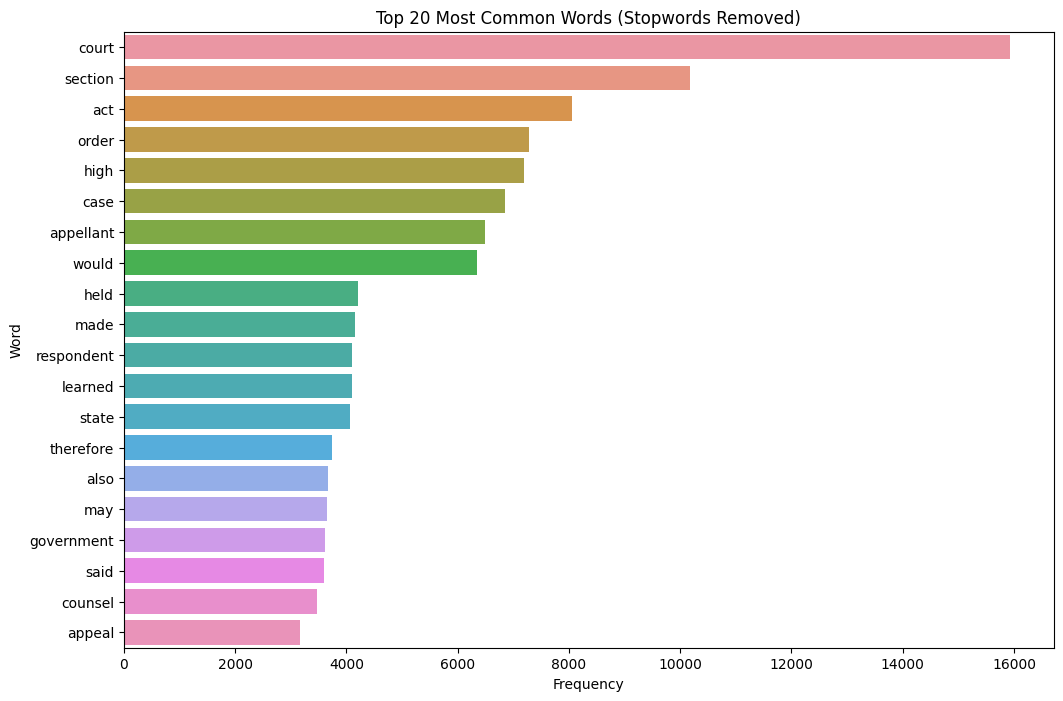

2025-10-22 09:37:55,306 - INFO - Analyzing n-gram frequencies...



Top 20 Bigrams (by PMI): [('hon', 'ble'), ('ad', 'hoc'), ('xxx', 'xxx'), ('west', 'bengal'), ('electoral', 'roll'), ('res', 'judicata'), ('identification', 'parade'), ('ultra', 'vires'), ('prima', 'facie'), ('bona', 'fide'), ('scheduled', 'tribes'), ('inter', 'alia'), ('letters', 'patent'), ('ballot', 'papers'), ('air', 'sc'), ('scheduled', 'castes'), ('rigorous', 'imprisonment'), ('mala', 'fide'), ('unlawful', 'assembly'), ('emphasis', 'supplied')]


2025-10-22 09:37:59,799 - INFO - Analyzing sentence length distribution...


Top 20 Trigrams (by PMI): [('xxx', 'xxx', 'xxx'), ('viva', 'voce', 'test'), ('castes', 'scheduled', 'tribes'), ('x', 'x', 'x'), ('citation', 'air', 'scr'), ('undergo', 'rigorous', 'imprisonment'), ('operate', 'res', 'judicata'), ('air', 'sc', 'scr'), ('scheduled', 'castes', 'scheduled'), ('test', 'identification', 'parade'), ('insc', 'air', 'sc'), ('r', 'e', 'r'), ('sc', 'scr', 'scc'), ('hindu', 'undivided', 'family'), ('inter', 'se', 'seniority'), ('restrictive', 'trade', 'practice'), ('members', 'unlawful', 'assembly'), ('arising', 'slp', 'c'), ('unfair', 'labour', 'practice'), ('income', 'profits', 'gains')]


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


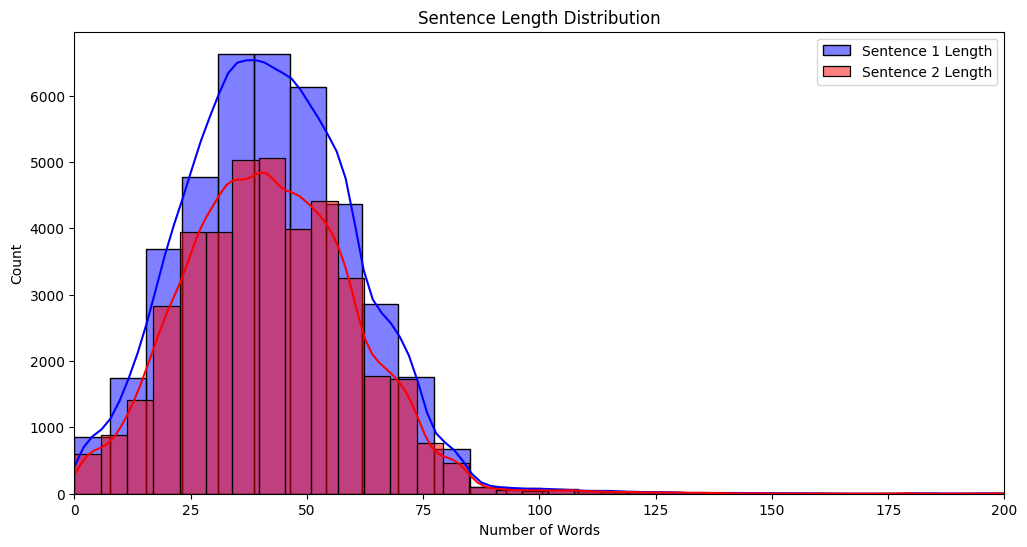

2025-10-22 09:38:00,908 - INFO - Analyzing readability and subjectivity by label...
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


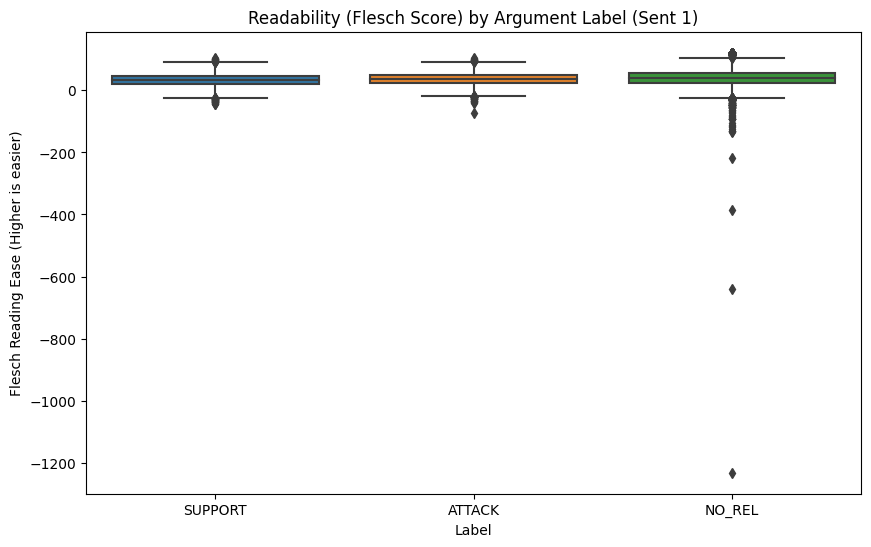

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


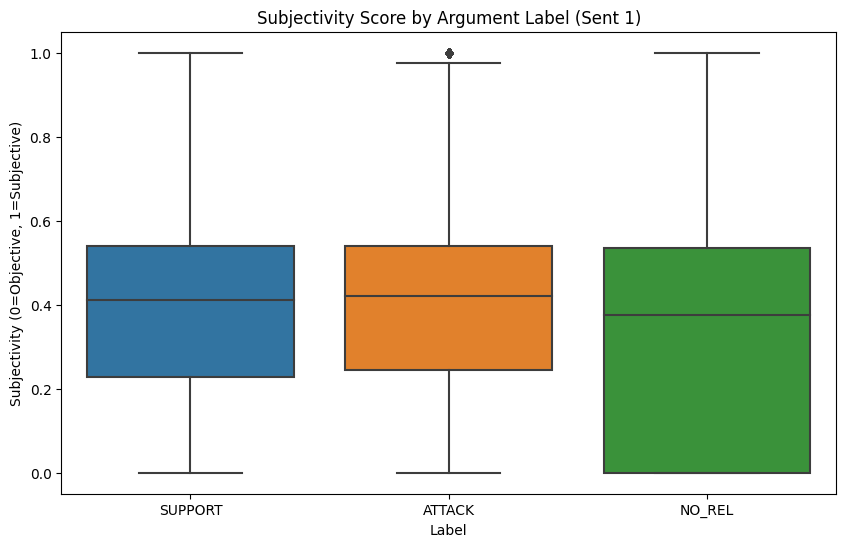

2025-10-22 09:38:16,269 - INFO - 
Creating a sample of 20000 pairs for topic modeling...
2025-10-22 09:38:16,304 - INFO - Created a sample of 30330 unique sentences.
2025-10-22 09:38:16,305 - INFO - 
========== STARTING LDA TOPIC MODELING ==========


---------------------------------


Preprocessing for LDA:   0%|          | 0/30330 [00:00<?, ?it/s]

2025-10-22 09:38:29,905 - INFO - Starting Topic Modeling (LDA)...
2025-10-22 09:38:29,906 - INFO - Training LDA model with 10 topics...
2025-10-22 09:39:05,900 - INFO - Generating pyLDAvis visualization...



--- LDA Topic Modeling Results ---
(0, '0.035*"land" + 0.034*"time" + 0.032*"service" + 0.031*"year" + 0.023*"respect" + 0.021*"notice" + 0.020*"contract" + 0.018*"effect" + 0.018*"board" + 0.016*"employee"')
(1, '0.143*"court" + 0.058*"high" + 0.041*"held" + 0.034*"also" + 0.028*"question" + 0.023*"view" + 0.021*"however" + 0.021*"evidence" + 0.019*"tribunal" + 0.019*"contended"')
(2, '0.048*"person" + 0.036*"reason" + 0.029*"upon" + 0.021*"jurisdiction" + 0.019*"present" + 0.016*"market" + 0.016*"compensation" + 0.016*"merely" + 0.015*"result" + 0.014*"raised"')
(3, '0.068*"appellant" + 0.061*"order" + 0.044*"respondent" + 0.030*"learned" + 0.028*"made" + 0.028*"appeal" + 0.026*"said" + 0.026*"counsel" + 0.021*"right" + 0.019*"article"')
(4, '0.152*"section" + 0.057*"provision" + 0.046*"could" + 0.036*"power" + 0.034*"party" + 0.033*"within" + 0.033*"must" + 0.031*"proceeding" + 0.021*"offence" + 0.020*"agreement"')
(5, '0.034*"property" + 0.034*"sale" + 0.033*"date" + 0.033*"part" 

...

2025-10-22 09:44:58,051 - BERTopic - Embedding - Completed ✓
2025-10-22 09:44:58,052 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-22 09:45:14,008 - BERTopic - Dimensionality - Completed ✓
2025-10-22 09:45:14,011 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-22 09:45:17,731 - BERTopic - Cluster - Completed ✓
2025-10-22 09:45:17,739 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-22 09:45:18,404 - BERTopic - Representation - Completed ✓



--- BERTopic Results for InLegalBERT ---
Top 10 Topics:
   Topic  Count                               Name  \
0     -1    205                    -1_the_of_by_in   
1      0  29619                     0_the_of_to_in   
2      1    283                 1_insc_air_scr_scc   
3      2     87         2_follows_as_reads_section   
4      3     83          3_2008_12_august_november   
5      4     53  4_arijit_pasayat_delhi_raveendran   

                                      Representation  \
0  [the, of, by, in, civil, appeal, delivered, ju...   
1     [the, of, to, in, that, and, is, was, not, by]   
2  [insc, air, scr, scc, citation, for, 1995, 200...   
3  [follows, as, reads, section, under, relevant,...   
4  [2008, 12, august, november, etc, april, 13, v...   
5  [arijit, pasayat, delhi, raveendran, dr, new, ...   

                                 Representative_Docs  
0  [Facts have been set out in detail by Brother ...  
1  [The appellant contended that rule 17(2 ) of t...  
2  [CI

Visualizing intertopic distance map...


Visualizing topic similarity heatmap...


2025-10-22 09:45:18,599 - INFO - --- BERTopic Analysis for InLegalBERT Complete ---
2025-10-22 09:45:18,599 - INFO - ==================================================
2025-10-22 09:45:18,657 - INFO - 
========== ALL ANALYSES COMPLETE ==========


In [8]:
# ==============================================================================
# === 6. MAIN EXECUTION
# ==============================================================================

if __name__ == '__main__':
    config = AnalysisConfig()
    logger.info(f"Using device: {config.DEVICE}")

    full_df = load_full_data(config)
    
    if full_df is not None:
        
        # --- 1. Lexical Analysis ---
        # This runs on the full dataframe and is relatively fast.
        logger.info("\n========== STARTING LEXICAL ANALYSIS ==========")
        perform_lexical_analysis(full_df)
        
        # --- 2. Create Sampled Doc List for Topic Modeling ---
        # To keep it simple, we sample for LDA and BERTopic
        logger.info(f"\nCreating a sample of {config.TOPIC_MODEL_SAMPLE_SIZE} pairs for topic modeling...")
        sampled_df = full_df.sample(
            n=config.TOPIC_MODEL_SAMPLE_SIZE, 
            random_state=42
        )
        # Combine sent1 and sent2 from the sample, get unique sentences
        docs = pd.concat([sampled_df['sent1'], sampled_df['sent2']]).dropna().unique().tolist()
        logger.info(f"Created a sample of {len(docs)} unique sentences.")

        # --- 3. LDA Topic Modeling ---
        logger.info("\n========== STARTING LDA TOPIC MODELING ==========")
        # Preprocess text for LDA
        processed_docs = [preprocess_text_for_lda(doc) for doc in tqdm(docs, desc="Preprocessing for LDA")]
        dictionary = Dictionary(processed_docs)
        dictionary.filter_extremes(no_below=15, no_above=0.5, keep_n=100000)
        corpus = [dictionary.doc2bow(doc) for doc in processed_docs]
        
        # Run LDA and get visualization
        lda_vis = perform_topic_modeling_lda(processed_docs, dictionary, corpus, num_topics=10)
        
        # Display the interactive LDA visualization
        print("Displaying LDA Visualization...")
        display(lda_vis)

        # --- 4. BERTopic Modeling Comparison ---
        logger.info("\n========== STARTING BERTOPIC MODELING COMPARISON ==========")
        
        for model_key, model_name in BERTOPIC_MODELS.items():
            perform_bertopic_modeling(docs, model_name, model_key)
            
        logger.info("\n========== ALL ANALYSES COMPLETE ==========")